# Univariate Analysis
Univariate Analysis is the process of examining one variable at a time to understand its characteristics, distribution, and statistical properties. It is the first stage of data analysis after data cleaning and provides valuable insights into individual features before exploring relationships between multiple variables.

#### Importing Required Libraries 

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import plotly.graph_objects as go
from plotly.subplots import make_subplots

#### Load the clean titanic dataset


In [42]:
df=pd.read_csv(r'F:\Anas\DATA_SCIENCE_POTPOLIO\06-Exploratory-Data-Analysis-EDA\clean_titanic.csv')
df.head()

,survived,pclass,sex,age,siblings_spouses,parents_children,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


In [43]:
# Numerical Features
numerical_features = df.select_dtypes(include="number").columns
print("Numerical Features:")
print(numerical_features)

# Categorical Features
categorical_features = df.select_dtypes(include=["object", "category"]).columns
print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
Index(['survived', 'pclass', 'age', 'siblings_spouses', 'parents_children',
       'fare'],
      dtype='str')

Categorical Features:
Index(['sex', 'embarked', 'class', 'who', 'embark_town', 'alive'], dtype='str')


C:\Users\Pickus Games\AppData\Local\Temp\ipykernel_14848\367874241.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.select_dtypes(include=["object", "category"]).columns


#### Statistical Analysis

In [44]:
df.describe()

,survived,pclass,age,siblings_spouses,parents_children,fare
count,775.000000,775.000000,775.000000,775.000000,775.000000,775.000000
mean,0.412903,2.246452,29.581187,0.529032,0.420645,34.878403
std,0.492674,0.853574,13.766359,0.990326,0.840565,52.408474
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,21.000000,0.000000,0.000000,8.050000
50%,0.000000,3.000000,28.000000,0.000000,0.000000,15.900000
75%,1.000000,3.000000,36.000000,1.000000,1.000000,34.197900
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [45]:
df.describe(include=["object", "category"])

C:\Users\Pickus Games\AppData\Local\Temp\ipykernel_14848\2615815932.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include=["object", "category"])


,sex,embarked,class,who,embark_town,alive
count,775,775,775,775,773,775
unique,2,3,3,3,3,2
top,male,S,Third,man,Southampton,no
freq,483,562,401,443,560,455


In [46]:
print("Mean:\n", df.mean(numeric_only=True))

Mean:
 survived             0.412903
pclass               2.246452
age                 29.581187
siblings_spouses     0.529032
parents_children     0.420645
fare                34.878403
adult_male           0.571613
alone                0.563871
dtype: float64


In [47]:
print("\nMedian:\n", df.median(numeric_only=True))


Median:
 survived             0.0
pclass               3.0
age                 28.0
siblings_spouses     0.0
parents_children     0.0
fare                15.9
adult_male           1.0
alone                1.0
dtype: float64


In [48]:
print("\nMode:\n", df.mode().iloc[0])


Mode:
 survived                      0
pclass                        3
sex                        male
age                        28.0
siblings_spouses              0
parents_children              0
fare                       13.0
embarked                      S
class                     Third
who                         man
adult_male                 True
embark_town         Southampton
alive                        no
alone                      True
Name: 0, dtype: object


In [49]:
print("Minimum:\n", df.min(numeric_only=True))

Minimum:
 survived                0
pclass                  1
age                  0.42
siblings_spouses        0
parents_children        0
fare                  0.0
adult_male          False
alone               False
dtype: object


In [50]:
print("\nMaximum:\n", df.max(numeric_only=True))


Maximum:
 survived                   1
pclass                     3
age                     80.0
siblings_spouses           8
parents_children           6
fare                512.3292
adult_male              True
alone                   True
dtype: object


In [51]:
print("\nVariance:\n", df.var(numeric_only=True))


Variance:
 survived               0.242727
pclass                 0.728589
age                  189.512628
siblings_spouses       0.980745
parents_children       0.706550
fare                2746.648097
adult_male             0.245188
alone                  0.246238
dtype: float64


In [52]:
print("\nStandard Deviation:\n", df.std(numeric_only=True))


Standard Deviation:
 survived             0.492674
pclass               0.853574
age                 13.766359
siblings_spouses     0.990326
parents_children     0.840565
fare                52.408474
adult_male           0.495165
alone                0.496224
dtype: float64


#### Distribution Analysis

Distribution analysis helps us understand the frequency and shape of numerical data.

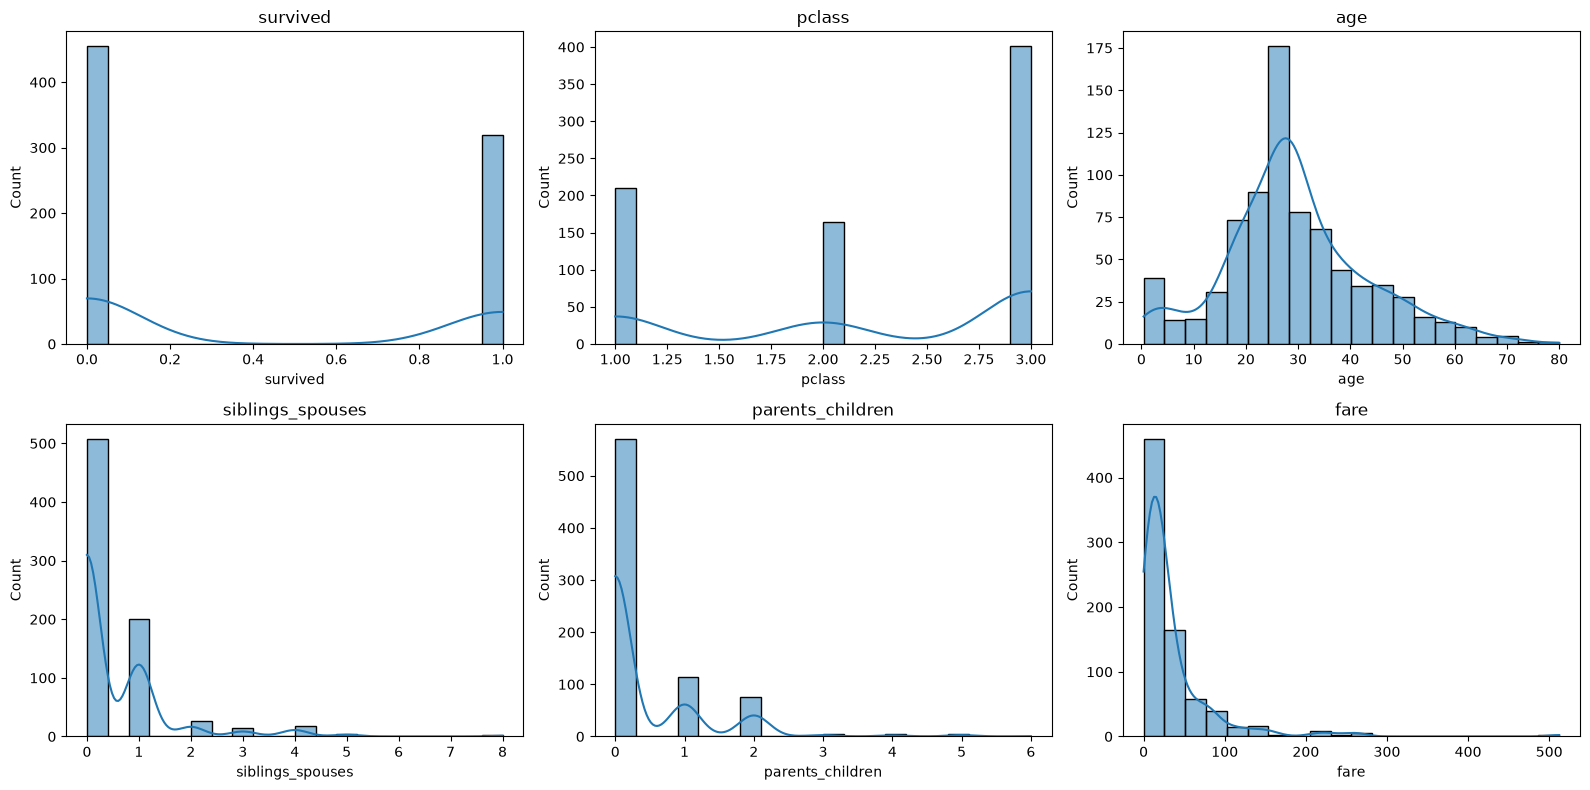

In [53]:
# Select numerical columns
numerical_columns = df.select_dtypes(include="number").columns
# Grid size
n_cols = 3
n_rows = (len(numerical_columns) + n_cols - 1) // n_cols

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

# Plot histograms
for i, column in enumerate(numerical_columns):
    sns.histplot(
        data=df,
        x=column,
        bins=20,
        kde=True,
        ax=axes[i]
    )

    axes[i].set_title(column)

# Remove empty plots
for i in range(len(numerical_columns), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

In [54]:
# Grid configuration
n_cols = 3
n_rows = (len(numerical_columns) + n_cols - 1) // n_cols

# Create subplot figure
fig = make_subplots(
    rows=n_rows,
    cols=n_cols,
    subplot_titles=numerical_columns
)

# Add histogram for each numerical feature
for i, column in enumerate(numerical_columns):
    
    row = i // n_cols + 1
    col = i % n_cols + 1

    fig.add_trace(
        go.Histogram(
            x=df[column],
            nbinsx=20,
            name=column,
            showlegend=False
        ),
        row=row,
        col=col
    )

# Update layout
fig.update_layout(
    title="Distribution of Numerical Features",
    height=350 * n_rows,
    width=1200,
    template="plotly_white"
)

fig.show()

#### Skewness Analysis

In [55]:
df.skew(numeric_only=True)

survived            0.354483
pclass             -0.494767
age                 0.441987
siblings_spouses    3.036078
parents_children    2.613347
fare                4.549950
adult_male         -0.289997
alone              -0.258094
dtype: float64

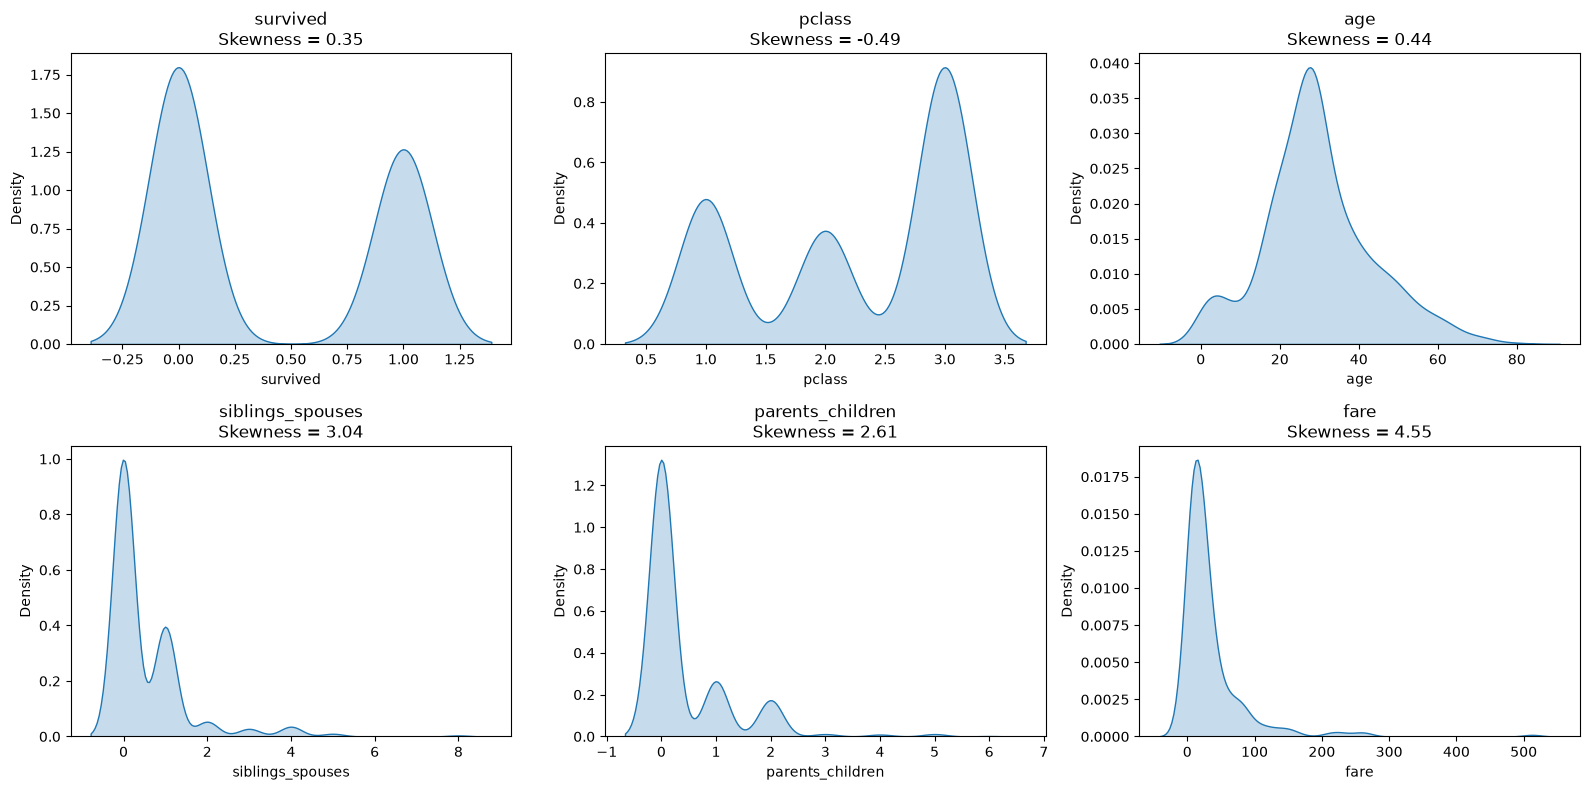

In [58]:
n_cols = 3
n_rows = (len(numerical_columns) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for i, column in enumerate(numerical_columns):

    skew_value = df[column].skew()

    sns.kdeplot(
        data=df,
        x=column,
        fill=True,
        ax=axes[i]
    )

    axes[i].set_title(f"{column}\nSkewness = {skew_value:.2f}")
    axes[i].set_xlabel(column)
    axes[i].set_ylabel("Density")

for i in range(len(numerical_columns), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()

plt.show()

#### Outlier Detection

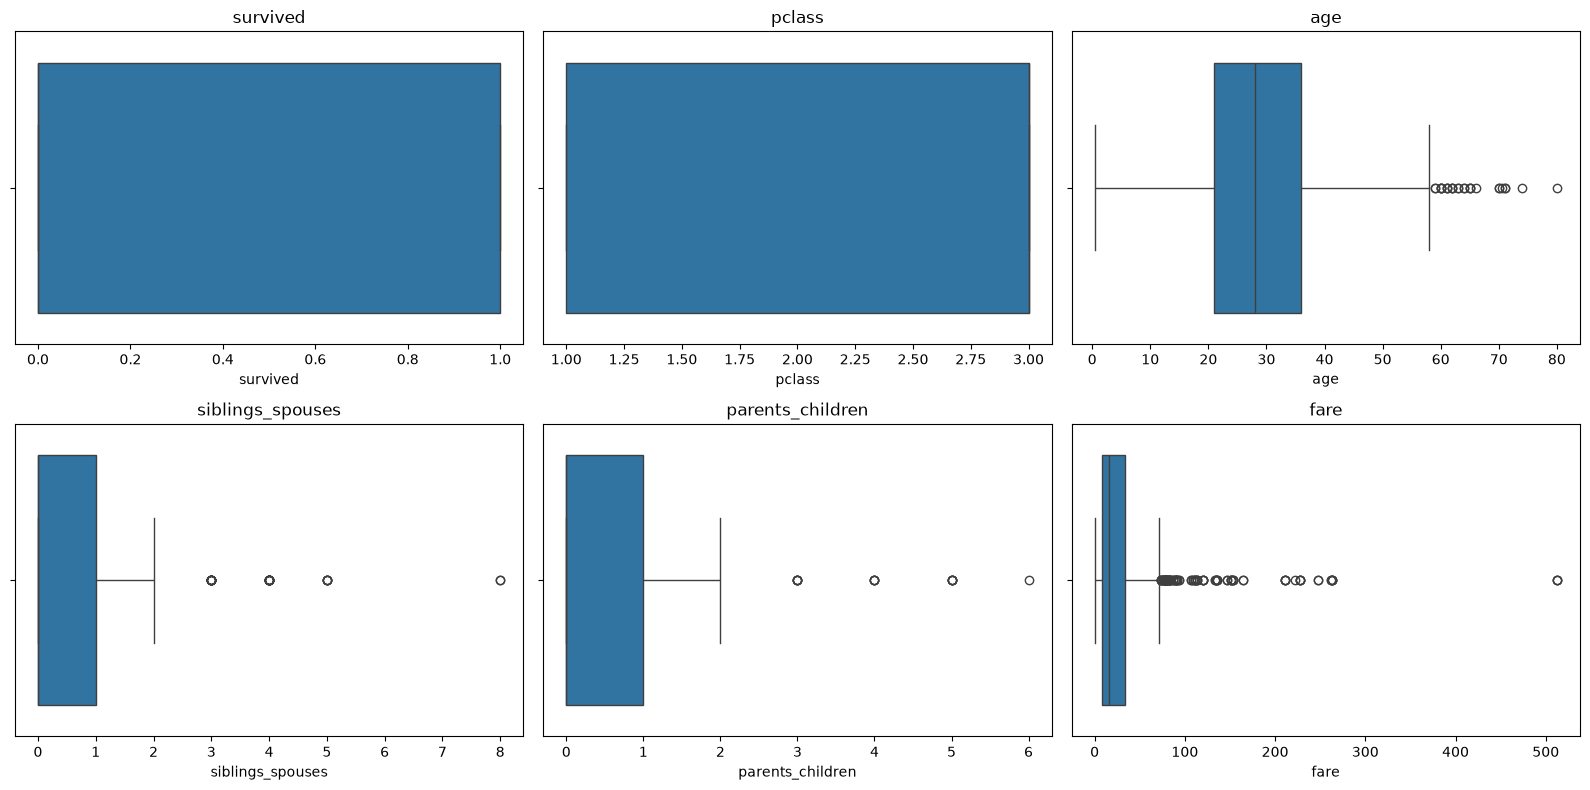

In [59]:
n_cols = 3
n_rows = (len(numerical_columns) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for i, column in enumerate(numerical_columns):

    sns.boxplot(
        x=df[column],
        ax=axes[i]
    )

    axes[i].set_title(column)

for i in range(len(numerical_columns), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

In [60]:
outlier_summary = []

for column in numerical_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower) |
        (df[column] > upper)
    ]

    outlier_summary.append({
        "Feature": column,
        "Outliers": len(outliers)
    })

outlier_df = pd.DataFrame(outlier_summary)

outlier_df

,Feature,Outliers
0,survived,0
1,pclass,0
2,age,27
3,siblings_spouses,39
4,parents_children,15
5,fare,102


In [62]:
for column in numerical_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower) |
        (df[column] > upper)
    ]

    percentage = (len(outliers) / len(df)) * 100

    print(f"{column}: {percentage:.2f}%")

survived: 0.00%
pclass: 0.00%
age: 3.48%
siblings_spouses: 5.03%
parents_children: 1.94%
fare: 13.16%
